In [1]:
%pip -q install openpyxl

import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
try:
    from google.colab import files
    uploaded = files.upload()

    excel_files = [name for name in uploaded.keys() if name.lower().endswith(".xlsx")]
    if not excel_files:
        raise FileNotFoundError("No .xlsx file was uploaded.")

    file_path = excel_files[0]
except ImportError:
    # Fallback for local Jupyter
    file_path = input("Enter the path to the Excel file: ").strip()

print(f"Using file: {file_path}")

Saving FIFA_World_Cup_2026_Yellow_Cards_Dataset.xlsx to FIFA_World_Cup_2026_Yellow_Cards_Dataset.xlsx
Using file: FIFA_World_Cup_2026_Yellow_Cards_Dataset.xlsx


In [3]:
xls = pd.ExcelFile(file_path)
print("Available sheets:")
print(xls.sheet_names)

required_sheets = {"Matches_Raw", "Cards_Raw"}
missing_sheets = required_sheets - set(xls.sheet_names)

if missing_sheets:
    raise ValueError(f"Missing required sheet(s): {missing_sheets}")

matches_raw = pd.read_excel(file_path, sheet_name="Matches_Raw")
cards_raw = pd.read_excel(file_path, sheet_name="Cards_Raw")

team_match_check = (
    pd.read_excel(file_path, sheet_name="Team_Match_Check")
    if "Team_Match_Check" in xls.sheet_names
    else None
)

print(f"Matches_Raw shape: {matches_raw.shape}")
print(f"Cards_Raw shape:   {cards_raw.shape}")

display(matches_raw.head())
display(cards_raw.head())

Available sheets:
['Matches_Raw', 'Cards_Raw', 'Team_Match_Check', 'Data_Dictionary', 'FIFA_Verified_Samples']
Matches_Raw shape: (104, 28)
Cards_Raw shape:   (284, 10)


,match_id,phase,phase_order,is_played,date_utc,date_local,local_hour,local_slot,venue_id,venue_name,city,country,tz,home_id,home_team,away_id,away_team,home_score,away_score,total_goals,is_draw,winner_id,winner_team,loser_id,loser_team,decided_by,attendance,source_url
0,760415,group-stage,0,1,2026-06-11T19:00Z,"46,184.7917",13,midday,1672,Estadio Banorte,Mexico City,Mexico,America/Mexico_City,203,Mexico,467,South Africa,2,0,2,0,203.0000,Mexico,467.0000,South Africa,regulation,80824,https://huggingface.co/datasets/Mr-Bridge/fifa...
1,760414,group-stage,0,1,2026-06-12T02:00Z,"46,185.0833",20,evening,5009,Estadio Akron,Guadalajara,Mexico,America/Mexico_City,451,South Korea,450,Czechia,2,1,3,0,451.0000,South Korea,450.0000,Czechia,regulation,44985,https://huggingface.co/datasets/Mr-Bridge/fifa...
2,760416,group-stage,0,1,2026-06-12T19:00Z,"46,185.7917",15,afternoon,10143,BMO Field,Toronto,Canada,America/Toronto,206,Canada,452,Bosnia-Herzegovina,1,1,2,1,NaN,NaN,NaN,NaN,regulation,43002,https://huggingface.co/datasets/Mr-Bridge/fifa...
3,760417,group-stage,0,1,2026-06-13T01:00Z,"46,186.0417",18,evening,9115,SoFi Stadium,"Inglewood, California",USA,America/Los_Angeles,660,United States,210,Paraguay,4,1,5,0,660.0000,United States,210.0000,Paraguay,regulation,70492,https://huggingface.co/datasets/Mr-Bridge/fifa...
4,760420,group-stage,0,1,2026-06-13T19:00Z,"46,186.7917",12,midday,5960,Levi's Stadium,"Santa Clara, California",USA,America/Los_Angeles,4398,Qatar,475,Switzerland,1,1,2,1,NaN,NaN,NaN,NaN,regulation,67966,https://huggingface.co/datasets/Mr-Bridge/fifa...


,match_id,phase,minute,minute_bucket,team_id,team,card_type,type,player,source_url
0,760415,group-stage,17,16-30,467,South Africa,yellow,Yellow Card,Teboho Mokoena,https://huggingface.co/datasets/Mr-Bridge/fifa...
1,760415,group-stage,23,16-30,203,Mexico,yellow,Yellow Card,Brian Gutiérrez,https://huggingface.co/datasets/Mr-Bridge/fifa...
2,760415,group-stage,49,46-60,467,South Africa,red,Red Card,Sphephelo Sithole,https://huggingface.co/datasets/Mr-Bridge/fifa...
3,760415,group-stage,74,61-75,467,South Africa,yellow,Yellow Card,Nkosinathi Sibisi,https://huggingface.co/datasets/Mr-Bridge/fifa...
4,760415,group-stage,84,76-90,467,South Africa,red,Red Card,Themba Zwane,https://huggingface.co/datasets/Mr-Bridge/fifa...


In [4]:
required_match_cols = {
    "match_id", "phase", "date_utc", "home_team", "away_team",
    "home_score", "away_score", "winner_team", "loser_team", "decided_by"
}

required_card_cols = {
    "match_id", "team", "card_type", "minute", "player"
}

missing_match_cols = required_match_cols - set(matches_raw.columns)
missing_card_cols = required_card_cols - set(cards_raw.columns)

if missing_match_cols:
    raise ValueError(f"Missing match columns: {missing_match_cols}")

if missing_card_cols:
    raise ValueError(f"Missing card columns: {missing_card_cols}")

print("Unique matches:", matches_raw["match_id"].nunique())
print("Duplicate match IDs:", matches_raw["match_id"].duplicated().sum())
print("Duplicate card-event rows:", cards_raw.duplicated().sum())

print("\nCard types:")
print(cards_raw["card_type"].astype(str).str.lower().value_counts(dropna=False))

print("\nMissing values in key match fields:")
display(matches_raw[
    ["match_id", "phase", "date_utc", "home_team", "away_team",
     "home_score", "away_score", "decided_by"]
].isna().sum().to_frame("Missing"))

print("\nMissing values in key card fields:")
display(cards_raw[
    ["match_id", "team", "card_type", "minute", "player"]
].isna().sum().to_frame("Missing"))

Unique matches: 104
Duplicate match IDs: 0
Duplicate card-event rows: 0

Card types:
card_type
yellow    268
red        16
Name: count, dtype: int64

Missing values in key match fields:


,Missing
match_id,0
phase,0
date_utc,0
home_team,0
away_team,0
home_score,0
away_score,0
decided_by,0



Missing values in key card fields:


,Missing
match_id,0
team,0
card_type,0
minute,0
player,0


In [5]:
matches = matches_raw.copy()
cards = cards_raw.copy()

# Standardise important fields
matches["date_utc"] = pd.to_datetime(matches["date_utc"], errors="coerce", utc=True)
cards["card_type"] = cards["card_type"].astype(str).str.strip().str.lower()
cards["team"] = cards["team"].astype(str).str.strip()

# Keep only yellow-card events for the primary outcome
yellow_events = cards.loc[cards["card_type"].eq("yellow")].copy()

# Aggregate individual yellow-card events to team-match counts
yellow_counts = (
    yellow_events
    .groupby(["match_id", "team"], as_index=False)
    .size()
    .rename(columns={"size": "Yellow_Cards"})
)

# Build HOME team rows
home = pd.DataFrame({
    "Match_ID": matches["match_id"],
    "Date_UTC": matches["date_utc"],
    "Stage": matches["phase"],
    "Team": matches["home_team"],
    "Opponent": matches["away_team"],
    "Home_Away": "Home",
    "Goals_For": matches["home_score"],
    "Goals_Against": matches["away_score"],
    "Winner_Team": matches["winner_team"],
    "Loser_Team": matches["loser_team"],
    "Decided_By": matches["decided_by"]
})

# Build AWAY team rows
away = pd.DataFrame({
    "Match_ID": matches["match_id"],
    "Date_UTC": matches["date_utc"],
    "Stage": matches["phase"],
    "Team": matches["away_team"],
    "Opponent": matches["home_team"],
    "Home_Away": "Away",
    "Goals_For": matches["away_score"],
    "Goals_Against": matches["home_score"],
    "Winner_Team": matches["winner_team"],
    "Loser_Team": matches["loser_team"],
    "Decided_By": matches["decided_by"]
})

team_match = pd.concat([home, away], ignore_index=True)

# Assign W/L/D using official winner information where available
team_match["Result"] = np.where(
    team_match["Winner_Team"].isna(),
    "D",
    np.where(team_match["Team"].eq(team_match["Winner_Team"]), "W", "L")
)

# Merge yellow-card counts
team_match = team_match.merge(
    yellow_counts,
    how="left",
    left_on=["Match_ID", "Team"],
    right_on=["match_id", "team"]
)

# No card-event row means zero yellow cards for that team-match
team_match["Yellow_Cards"] = team_match["Yellow_Cards"].fillna(0).astype(int)

# Derived analytical variables
team_match["Analysis_Group"] = np.where(
    team_match["Result"].eq("W"),
    "Winning",
    "Non-Winning"
)

team_match["Score_Was_Draw"] = np.where(
    team_match["Goals_For"].eq(team_match["Goals_Against"]),
    "Yes",
    "No"
)

team_match["Phase_Group"] = np.where(
    team_match["Stage"].astype(str).eq("group-stage"),
    "Group Stage",
    "Knockout"
)

# Clean up merge helper columns
team_match = team_match.drop(columns=["match_id", "team"], errors="ignore")

# Reorder columns
ordered_cols = [
    "Match_ID", "Date_UTC", "Stage", "Phase_Group", "Team", "Opponent",
    "Home_Away", "Goals_For", "Goals_Against", "Result", "Analysis_Group",
    "Yellow_Cards", "Decided_By", "Score_Was_Draw"
]
team_match = team_match[ordered_cols].sort_values(
    ["Date_UTC", "Match_ID", "Home_Away"]
).reset_index(drop=True)

print("Analytical dataset created.")
print("Shape:", team_match.shape)
display(team_match.head(10))

Analytical dataset created.
Shape: (208, 14)


,Match_ID,Date_UTC,Stage,Phase_Group,Team,Opponent,Home_Away,Goals_For,Goals_Against,Result,Analysis_Group,Yellow_Cards,Decided_By,Score_Was_Draw
0,760415,2026-06-11 19:00:00+00:00,group-stage,Group Stage,South Africa,Mexico,Away,0,2,L,Non-Winning,2,regulation,No
1,760415,2026-06-11 19:00:00+00:00,group-stage,Group Stage,Mexico,South Africa,Home,2,0,W,Winning,1,regulation,No
2,760414,2026-06-12 02:00:00+00:00,group-stage,Group Stage,Czechia,South Korea,Away,1,2,L,Non-Winning,0,regulation,No
3,760414,2026-06-12 02:00:00+00:00,group-stage,Group Stage,South Korea,Czechia,Home,2,1,W,Winning,1,regulation,No
4,760416,2026-06-12 19:00:00+00:00,group-stage,Group Stage,Bosnia-Herzegovina,Canada,Away,1,1,D,Non-Winning,3,regulation,Yes
5,760416,2026-06-12 19:00:00+00:00,group-stage,Group Stage,Canada,Bosnia-Herzegovina,Home,1,1,D,Non-Winning,2,regulation,Yes
6,760417,2026-06-13 01:00:00+00:00,group-stage,Group Stage,Paraguay,United States,Away,1,4,L,Non-Winning,5,regulation,No
7,760417,2026-06-13 01:00:00+00:00,group-stage,Group Stage,United States,Paraguay,Home,4,1,W,Winning,1,regulation,No
8,760420,2026-06-13 19:00:00+00:00,group-stage,Group Stage,Switzerland,Qatar,Away,1,1,D,Non-Winning,1,regulation,Yes
9,760420,2026-06-13 19:00:00+00:00,group-stage,Group Stage,Qatar,Switzerland,Home,1,1,D,Non-Winning,2,regulation,Yes


In [6]:
# 1. Two team rows per match
rows_per_match = team_match.groupby("Match_ID").size()
assert rows_per_match.eq(2).all(), "Some matches do not have exactly two team rows."

# 2. No duplicate team-match rows
assert not team_match.duplicated(["Match_ID", "Team"]).any(),     "Duplicate team-match rows detected."

# 3. Yellow-card totals reconcile to the raw card-event table
raw_yellow_total = int(yellow_events.shape[0])
aggregated_yellow_total = int(team_match["Yellow_Cards"].sum())

assert raw_yellow_total == aggregated_yellow_total,     "Yellow-card totals do not reconcile."

# 4. Logical range check
assert team_match["Yellow_Cards"].ge(0).all(),     "Negative yellow-card counts detected."

print("All core validation checks passed.")
print(f"Matches represented: {team_match['Match_ID'].nunique()}")
print(f"Team-match observations: {len(team_match)}")
print(f"Raw yellow-card events: {raw_yellow_total}")
print(f"Aggregated yellow cards: {aggregated_yellow_total}")

print("\nOutcome-group counts:")
display(team_match["Analysis_Group"].value_counts().to_frame("Observations"))

print("\nDecision method:")
display(team_match["Decided_By"].value_counts().to_frame("Matches x team rows"))

All core validation checks passed.
Matches represented: 104
Team-match observations: 208
Raw yellow-card events: 268
Aggregated yellow cards: 268

Outcome-group counts:


,Observations
Analysis_Group,
Non-Winning,124
Winning,84



Decision method:


,Matches x team rows
Decided_By,
regulation,190
extra_time,10
shootout,8


In [7]:
# Optional cross-check against the prepared verification sheet
if team_match_check is not None:
    check_cols = ["Match_ID", "Team", "Yellow_Cards", "Result"]
    left = team_match[check_cols].copy()
    right = team_match_check[check_cols].copy()

    comparison = left.merge(
        right,
        on=["Match_ID", "Team"],
        how="outer",
        suffixes=("_Wrangled", "_Check"),
        indicator=True
    )

    comparison["Yellow_Cards_Match"] = (
        comparison["Yellow_Cards_Wrangled"] == comparison["Yellow_Cards_Check"]
    )
    comparison["Result_Match"] = (
        comparison["Result_Wrangled"] == comparison["Result_Check"]
    )

    mismatch = comparison[
        (comparison["_merge"] != "both") |
        (~comparison["Yellow_Cards_Match"]) |
        (~comparison["Result_Match"])
    ]

    print(f"Verification mismatches: {len(mismatch)}")
    if len(mismatch) == 0:
        print("Wrangled dataset matches the supplied check sheet.")
    else:
        display(mismatch.head(20))
else:
    print("Team_Match_Check sheet not available; this verification step was skipped.")

Verification mismatches: 0
Wrangled dataset matches the supplied check sheet.


In [8]:
SAMPLE_FRAC = 0.80

match_frame = (
    team_match[["Match_ID", "Phase_Group"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

sampled_matches = (
    match_frame
    .groupby("Phase_Group", group_keys=False)
    .sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
)

sample = team_match[
    team_match["Match_ID"].isin(sampled_matches["Match_ID"])
].copy()

print(f"Population matches: {team_match['Match_ID'].nunique()}")
print(f"Sampled matches:    {sample['Match_ID'].nunique()}")
print(f"Population team-match rows: {len(team_match)}")
print(f"Sample team-match rows:     {len(sample)}")

print("\nSampled matches by tournament phase:")
display(sampled_matches["Phase_Group"].value_counts().to_frame("Matches"))

print("\nSample observations by analysis group:")
display(sample["Analysis_Group"].value_counts().to_frame("Observations"))

Population matches: 104
Sampled matches:    84
Population team-match rows: 208
Sample team-match rows:     168

Sampled matches by tournament phase:


,Matches
Phase_Group,
Group Stage,58
Knockout,26



Sample observations by analysis group:


,Observations
Analysis_Group,
Non-Winning,100
Winning,68


In [9]:
def descriptive_table(df):
    grouped = df.groupby("Analysis_Group")["Yellow_Cards"]

    output = grouped.agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        variance="var",
        minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        maximum="max",
        skewness=lambda x: stats.skew(x, bias=False)
    )

    output["IQR"] = output["Q3"] - output["Q1"]
    output["range"] = output["maximum"] - output["minimum"]
    return output

sample_descriptives = descriptive_table(sample)
population_descriptives = descriptive_table(team_match)

print("SAMPLE descriptive statistics")
display(sample_descriptives)

print("\nFULL-DATA descriptive statistics (sensitivity/reference)")
display(population_descriptives)

SAMPLE descriptive statistics


,n,mean,median,std,variance,minimum,Q1,Q3,maximum,skewness,IQR,range
Analysis_Group,,,,,,,,,,,,
Non-Winning,100,1.4400,1.0000,1.1487,1.3196,0,1.0000,2.0000,5,0.9046,1.0000,5
Winning,68,1.0147,1.0000,1.1262,1.2684,0,0.0000,1.2500,4,1.0038,1.2500,4



FULL-DATA descriptive statistics (sensitivity/reference)


,n,mean,median,std,variance,minimum,Q1,Q3,maximum,skewness,IQR,range
Analysis_Group,,,,,,,,,,,,
Non-Winning,124,1.4597,1.0000,1.1575,1.3398,0,1.0000,2.0000,5,0.9148,1.0000,5
Winning,84,1.0357,1.0000,1.0692,1.1433,0,0.0000,1.2500,4,0.9574,1.2500,4


## 9. Visual exploration

The following plots are created separately to keep each figure clear and interpretable.

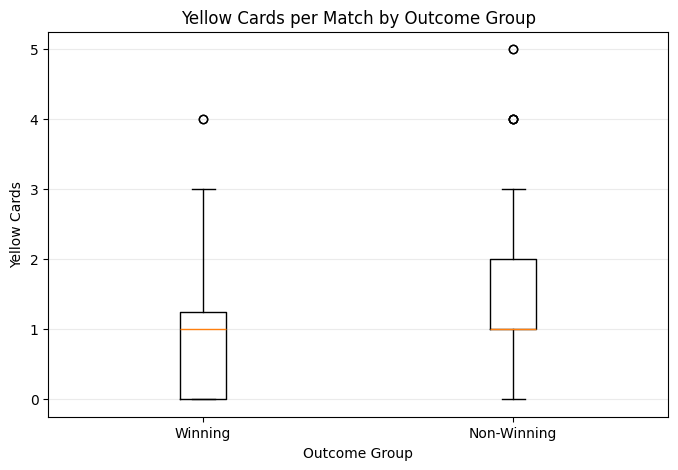

In [10]:
# Figure 1: Boxplot
winning_vals = sample.loc[
    sample["Analysis_Group"].eq("Winning"), "Yellow_Cards"
].to_numpy()

nonwinning_vals = sample.loc[
    sample["Analysis_Group"].eq("Non-Winning"), "Yellow_Cards"
].to_numpy()

plt.figure(figsize=(8, 5))
plt.boxplot(
    [winning_vals, nonwinning_vals],
    tick_labels=["Winning", "Non-Winning"]
)
plt.title("Yellow Cards per Match by Outcome Group")
plt.ylabel("Yellow Cards")
plt.xlabel("Outcome Group")
plt.grid(axis="y", alpha=0.25)
plt.show()

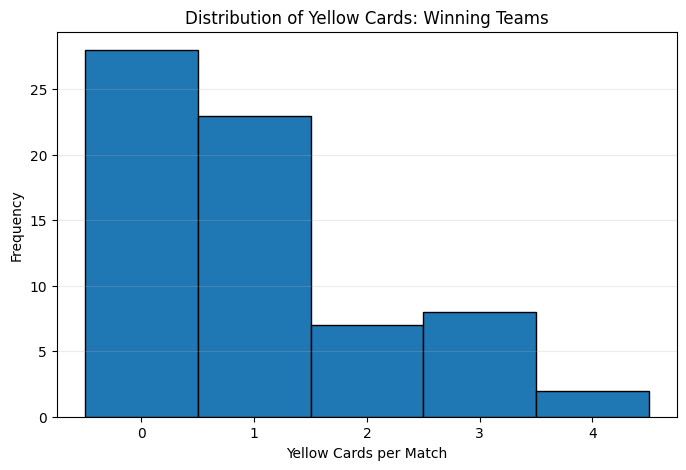

In [11]:
# Figure 2: Histogram for winning teams
plt.figure(figsize=(8, 5))
plt.hist(
    winning_vals,
    bins=np.arange(-0.5, winning_vals.max() + 1.5, 1),
    edgecolor="black"
)
plt.title("Distribution of Yellow Cards: Winning Teams")
plt.xlabel("Yellow Cards per Match")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.25)
plt.show()

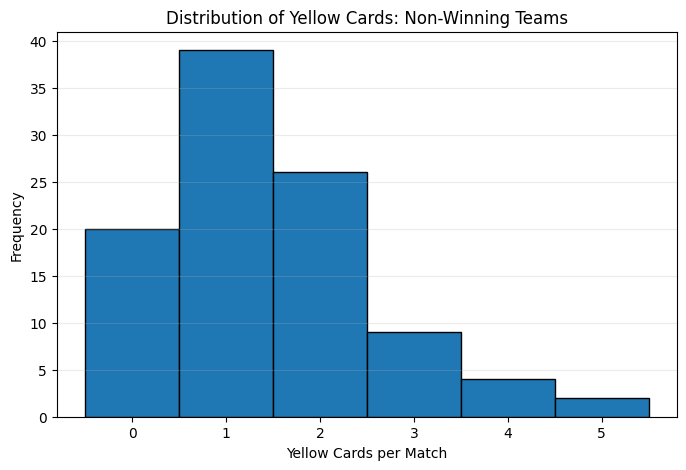

In [12]:
# Figure 3: Histogram for non-winning teams
plt.figure(figsize=(8, 5))
plt.hist(
    nonwinning_vals,
    bins=np.arange(-0.5, nonwinning_vals.max() + 1.5, 1),
    edgecolor="black"
)
plt.title("Distribution of Yellow Cards: Non-Winning Teams")
plt.xlabel("Yellow Cards per Match")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [13]:
def mean_ci(series, confidence=0.95):
    x = pd.Series(series).dropna().astype(float)
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    margin = tcrit * se
    return pd.Series({
        "n": n,
        "mean": mean,
        "SE": se,
        "CI_Lower": mean - margin,
        "CI_Upper": mean + margin
    })

group_ci = (
    sample
    .groupby("Analysis_Group")["Yellow_Cards"]
    .apply(mean_ci)
    .unstack()
)

print("95% confidence interval for each group mean:")
display(group_ci)

def welch_difference_ci(x, y, confidence=0.95):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)

    difference = mx - my
    se = np.sqrt(vx / nx + vy / ny)

    df = (vx / nx + vy / ny) ** 2 / (
        (vx / nx) ** 2 / (nx - 1) +
        (vy / ny) ** 2 / (ny - 1)
    )

    tcrit = stats.t.ppf((1 + confidence) / 2, df)
    lower = difference - tcrit * se
    upper = difference + tcrit * se

    return {
        "Mean_Difference_Winning_minus_NonWinning": difference,
        "SE": se,
        "df": df,
        "CI_Lower": lower,
        "CI_Upper": upper
    }

diff_ci = welch_difference_ci(winning_vals, nonwinning_vals)
print("\n95% CI for mean difference (Winning - Non-Winning):")
display(pd.DataFrame([diff_ci]))

95% confidence interval for each group mean:


,n,mean,SE,CI_Lower,CI_Upper
Analysis_Group,,,,,
Non-Winning,100.0000,1.4400,0.1149,1.2121,1.6679
Winning,68.0000,1.0147,0.1366,0.7421,1.2873



95% CI for mean difference (Winning - Non-Winning):


,Mean_Difference_Winning_minus_NonWinning,SE,df,CI_Lower,CI_Upper
0,-0.4253,0.1785,145.9079,-0.7780,-0.0726


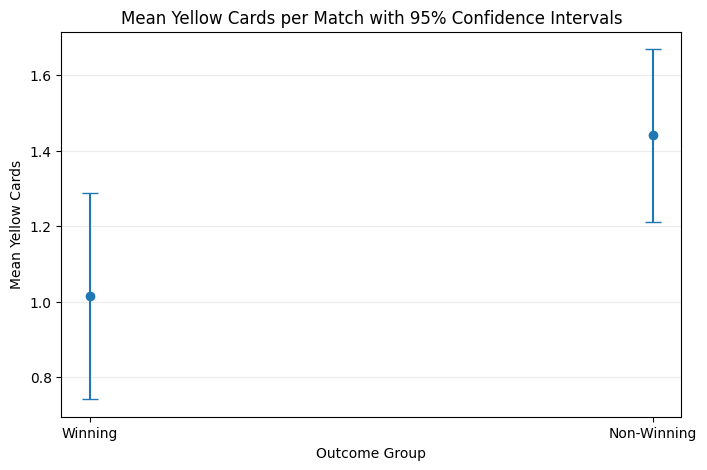

In [14]:
# Figure 4: Group means with 95% confidence intervals
ci_plot = group_ci.loc[["Winning", "Non-Winning"]].copy()
means = ci_plot["mean"].to_numpy()
lower_err = means - ci_plot["CI_Lower"].to_numpy()
upper_err = ci_plot["CI_Upper"].to_numpy() - means

plt.figure(figsize=(8, 5))
plt.errorbar(
    ["Winning", "Non-Winning"],
    means,
    yerr=[lower_err, upper_err],
    fmt="o",
    capsize=6
)
plt.title("Mean Yellow Cards per Match with 95% Confidence Intervals")
plt.xlabel("Outcome Group")
plt.ylabel("Mean Yellow Cards")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [15]:
# Shapiro-Wilk normality tests
shapiro_w = stats.shapiro(winning_vals)
shapiro_nw = stats.shapiro(nonwinning_vals)

normality_results = pd.DataFrame({
    "Group": ["Winning", "Non-Winning"],
    "W_Statistic": [shapiro_w.statistic, shapiro_nw.statistic],
    "p_value": [shapiro_w.pvalue, shapiro_nw.pvalue]
})

print("Shapiro-Wilk normality tests:")
display(normality_results)

# Brown-Forsythe / Levene test using median
levene_result = stats.levene(
    winning_vals,
    nonwinning_vals,
    center="median"
)

print(
    f"Brown-Forsythe/Levene test: "
    f"statistic={levene_result.statistic:.4f}, "
    f"p={levene_result.pvalue:.4f}"
)

def outlier_count(x):
    x = pd.Series(x)
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Fence": lower,
        "Upper_Fence": upper,
        "Outliers": int(((x < lower) | (x > upper)).sum())
    }

outlier_table = pd.DataFrame({
    "Winning": outlier_count(winning_vals),
    "Non-Winning": outlier_count(nonwinning_vals)
}).T

print("\nIQR outlier check:")
display(outlier_table)

Shapiro-Wilk normality tests:


,Group,W_Statistic,p_value
0,Winning,0.8079,0.0000
1,Non-Winning,0.8765,0.0000


Brown-Forsythe/Levene test: statistic=0.0002, p=0.9893

IQR outlier check:


,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outliers
Winning,0.0000,1.2500,1.2500,-1.8750,3.1250,2.0000
Non-Winning,1.0000,2.0000,1.0000,-0.5000,3.5000,6.0000


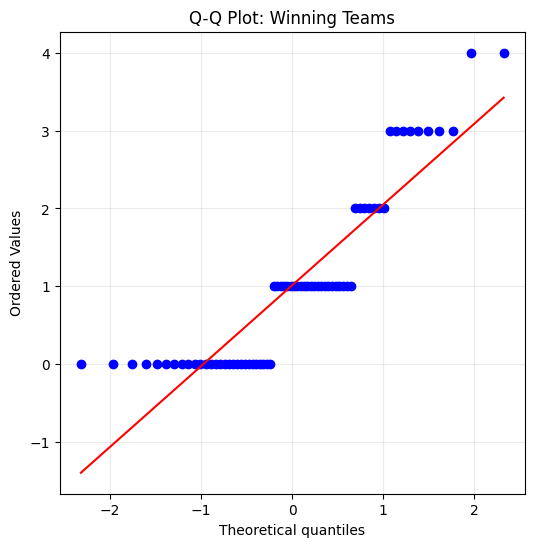

In [16]:
# Figure 5: Q-Q plot for winning teams
plt.figure(figsize=(6, 6))
stats.probplot(winning_vals, dist="norm", plot=plt)
plt.title("Q-Q Plot: Winning Teams")
plt.grid(alpha=0.25)
plt.show()

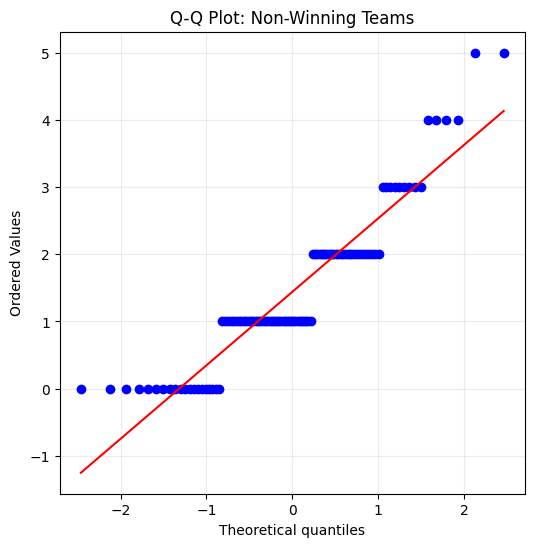

In [17]:
# Figure 6: Q-Q plot for non-winning teams
plt.figure(figsize=(6, 6))
stats.probplot(nonwinning_vals, dist="norm", plot=plt)
plt.title("Q-Q Plot: Non-Winning Teams")
plt.grid(alpha=0.25)
plt.show()

## 12. Primary inferential test: Welch two-sample t-test

### Hypotheses
\[
H_0: \mu_{Winning} = \mu_{NonWinning}
\]

\[
H_1: \mu_{Winning} \neq \mu_{NonWinning}
\]

Significance level:

\[
\alpha = 0.05
\]

A two-tailed Welch t-test is appropriate because the research question asks whether the two means are **different**, without specifying a direction.

In [18]:
ALPHA = 0.05

welch_test = stats.ttest_ind(
    winning_vals,
    nonwinning_vals,
    equal_var=False
)

print("Welch two-sample t-test")
print(f"t-statistic = {welch_test.statistic:.4f}")
print(f"p-value     = {welch_test.pvalue:.6f}")

if welch_test.pvalue < ALPHA:
    decision = "Reject H0"
    significance = "statistically significant"
else:
    decision = "Fail to reject H0"
    significance = "not statistically significant"

print(f"Decision at alpha = {ALPHA}: {decision}")
print(f"The sample difference is {significance}.")

Welch two-sample t-test
t-statistic = -2.3831
p-value     = 0.018456
Decision at alpha = 0.05: Reject H0
The sample difference is statistically significant.


In [19]:
def cohens_d_independent(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)

    pooled_sd = np.sqrt(
        ((nx - 1) * vx + (ny - 1) * vy) /
        (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_sd

def hedges_g(x, y):
    d = cohens_d_independent(x, y)
    nx, ny = len(x), len(y)
    df = nx + ny - 2
    correction = 1 - (3 / (4 * df - 1))
    return correction * d

d = cohens_d_independent(winning_vals, nonwinning_vals)
g = hedges_g(winning_vals, nonwinning_vals)

print(f"Cohen's d = {d:.4f}")
print(f"Hedges' g = {g:.4f}")

abs_g = abs(g)
if abs_g < 0.20:
    magnitude = "very small"
elif abs_g < 0.50:
    magnitude = "small"
elif abs_g < 0.80:
    magnitude = "medium"
else:
    magnitude = "large"

print(f"Approximate effect-size magnitude: {magnitude}")

Cohen's d = -0.3732
Hedges' g = -0.3715
Approximate effect-size magnitude: small


In [20]:
# Mann-Whitney U test
mw = stats.mannwhitneyu(
    winning_vals,
    nonwinning_vals,
    alternative="two-sided"
)

print("Mann-Whitney U robustness check")
print(f"U statistic = {mw.statistic:.4f}")
print(f"p-value     = {mw.pvalue:.6f}")

Mann-Whitney U robustness check
U statistic = 2600.5000
p-value     = 0.007037


In [21]:
# Bootstrap 95% CI for the difference in means
rng = np.random.default_rng(RANDOM_SEED)
N_BOOT = 10_000

boot_diffs = np.empty(N_BOOT)

for i in range(N_BOOT):
    boot_w = rng.choice(winning_vals, size=len(winning_vals), replace=True)
    boot_nw = rng.choice(nonwinning_vals, size=len(nonwinning_vals), replace=True)
    boot_diffs[i] = boot_w.mean() - boot_nw.mean()

boot_lower, boot_upper = np.percentile(boot_diffs, [2.5, 97.5])

print(
    "Bootstrap mean difference (Winning - Non-Winning) "
    f"95% CI: [{boot_lower:.4f}, {boot_upper:.4f}]"
)

Bootstrap mean difference (Winning - Non-Winning) 95% CI: [-0.7682, -0.0718]


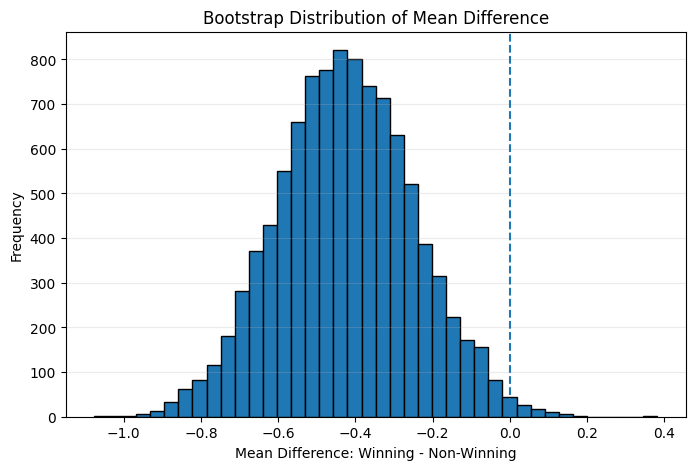

In [22]:
# Figure 7: Bootstrap distribution of mean differences
plt.figure(figsize=(8, 5))
plt.hist(boot_diffs, bins=40, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.title("Bootstrap Distribution of Mean Difference")
plt.xlabel("Mean Difference: Winning - Non-Winning")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [23]:
stage_summary = (
    team_match
    .groupby(["Phase_Group", "Analysis_Group"])["Yellow_Cards"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(stage_summary)

,Phase_Group,Analysis_Group,count,mean,median,std
0,Group Stage,Non-Winning,92,1.4239,1.0000,1.1117
1,Group Stage,Winning,52,0.9038,1.0000,0.9131
2,Knockout,Non-Winning,32,1.5625,1.0000,1.2936
3,Knockout,Winning,32,1.2500,1.0000,1.2700


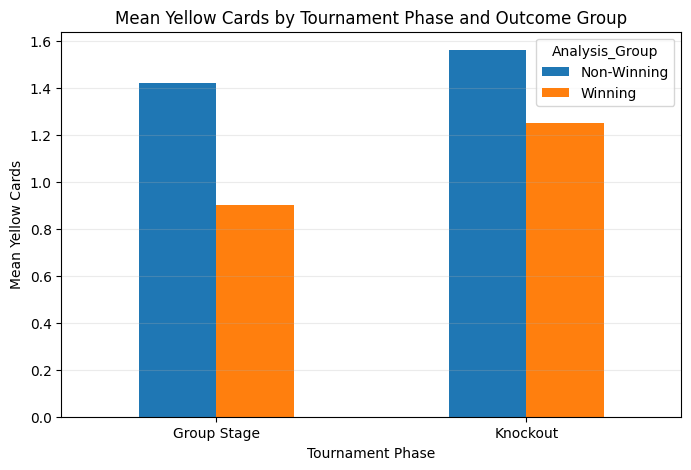

In [24]:
# Figure 8: Mean yellow cards by broad tournament phase and outcome group
pivot_means = (
    stage_summary
    .pivot(index="Phase_Group", columns="Analysis_Group", values="mean")
)

ax = pivot_means.plot(kind="bar", figsize=(8, 5))
ax.set_title("Mean Yellow Cards by Tournament Phase and Outcome Group")
ax.set_xlabel("Tournament Phase")
ax.set_ylabel("Mean Yellow Cards")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.show()

In [25]:
full_winning = team_match.loc[
    team_match["Analysis_Group"].eq("Winning"), "Yellow_Cards"
].to_numpy()

full_nonwinning = team_match.loc[
    team_match["Analysis_Group"].eq("Non-Winning"), "Yellow_Cards"
].to_numpy()

full_welch = stats.ttest_ind(
    full_winning,
    full_nonwinning,
    equal_var=False
)

print("Full-data sensitivity test:")
print(f"Winning mean     = {full_winning.mean():.4f}")
print(f"Non-winning mean = {full_nonwinning.mean():.4f}")
print(f"Mean difference  = {full_winning.mean() - full_nonwinning.mean():.4f}")
print(f"Welch t          = {full_welch.statistic:.4f}")
print(f"p-value          = {full_welch.pvalue:.6f}")

Full-data sensitivity test:
Winning mean     = 1.0357
Non-winning mean = 1.4597
Mean difference  = -0.4240
Welch t          = -2.7133
p-value          = 0.007283


In [26]:
w_mean = winning_vals.mean()
nw_mean = nonwinning_vals.mean()
mean_diff = w_mean - nw_mean

if welch_test.pvalue < ALPHA:
    inferential_sentence = (
        "The Welch two-sample t-test provides evidence of a statistically "
        "significant difference in mean yellow cards between the groups."
    )
else:
    inferential_sentence = (
        "The Welch two-sample t-test does not provide sufficient evidence "
        "of a statistically significant difference in mean yellow cards between the groups."
    )

direction_sentence = (
    "Winning teams received fewer yellow cards on average than non-winning teams."
    if mean_diff < 0
    else "Winning teams received more yellow cards on average than non-winning teams."
    if mean_diff > 0
    else "The sample means were equal."
)

interpretation = f'''
RESULT INTERPRETATION

Sample size:
- Winning observations: {len(winning_vals)}
- Non-winning observations: {len(nonwinning_vals)}

Mean yellow cards:
- Winning: {w_mean:.3f}
- Non-winning: {nw_mean:.3f}
- Difference (Winning - Non-Winning): {mean_diff:.3f}

95% CI for the mean difference:
[{diff_ci["CI_Lower"]:.3f}, {diff_ci["CI_Upper"]:.3f}]

Welch t-test:
t = {welch_test.statistic:.3f}
p = {welch_test.pvalue:.4f}

Effect size:
Hedges' g = {g:.3f} ({magnitude})

Decision:
{decision}

Interpretation:
{inferential_sentence}
{direction_sentence}

Caution:
Yellow cards are discrete count data and normality may be imperfect.
The two teams in the same match also share match context, so strict
independence is a limitation. The robustness checks and complete-data
sensitivity analysis should therefore be considered alongside the t-test.
'''

print(interpretation)


RESULT INTERPRETATION

Sample size:
- Winning observations: 68
- Non-winning observations: 100

Mean yellow cards:
- Winning: 1.015
- Non-winning: 1.440
- Difference (Winning - Non-Winning): -0.425

95% CI for the mean difference:
[-0.778, -0.073]

Welch t-test:
t = -2.383
p = 0.0185

Effect size:
Hedges' g = -0.371 (small)

Decision:
Reject H0

Interpretation:
The Welch two-sample t-test provides evidence of a statistically significant difference in mean yellow cards between the groups.
Winning teams received fewer yellow cards on average than non-winning teams.

Caution:
Yellow cards are discrete count data and normality may be imperfect.
The two teams in the same match also share match context, so strict
independence is a limitation. The robustness checks and complete-data
sensitivity analysis should therefore be considered alongside the t-test.



In [27]:
# Export cleaned datasets
team_match.to_csv("FIFA_2026_Yellow_Cards_Cleaned.csv", index=False)
sample.to_csv("FIFA_2026_Yellow_Cards_Sample.csv", index=False)

# Excel does not support timezone-aware datetimes.
# Create export-only copies with timezone information removed.
team_match_excel = team_match.copy()
sample_excel = sample.copy()

for df_export in [team_match_excel, sample_excel]:
    if "Date_UTC" in df_export.columns:
        df_export["Date_UTC"] = pd.to_datetime(
            df_export["Date_UTC"], errors="coerce", utc=True
        ).dt.tz_localize(None)

# Export main tables to Excel
with pd.ExcelWriter(
    "FIFA_2026_Yellow_Cards_Analysis_Results.xlsx",
    engine="openpyxl"
) as writer:
    team_match_excel.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    sample_excel.to_excel(writer, sheet_name="Sample", index=False)
    sample_descriptives.to_excel(writer, sheet_name="Descriptives")
    group_ci.to_excel(writer, sheet_name="Group_CI")
    pd.DataFrame([diff_ci]).to_excel(
        writer,
        sheet_name="Difference_CI",
        index=False
    )
    normality_results.to_excel(
        writer,
        sheet_name="Normality",
        index=False
    )
    outlier_table.to_excel(writer, sheet_name="Outliers")
    stage_summary.to_excel(
        writer,
        sheet_name="Stage_Summary",
        index=False
    )

print("Export complete:")
print("- FIFA_2026_Yellow_Cards_Cleaned.csv")
print("- FIFA_2026_Yellow_Cards_Sample.csv")
print("- FIFA_2026_Yellow_Cards_Analysis_Results.xlsx")

Export complete:
- FIFA_2026_Yellow_Cards_Cleaned.csv
- FIFA_2026_Yellow_Cards_Sample.csv
- FIFA_2026_Yellow_Cards_Analysis_Results.xlsx


In [28]:
# Optional: download the final exported files when running in Google Colab
try:
    from google.colab import files

    files.download("FIFA_2026_Yellow_Cards_Cleaned.csv")
    files.download("FIFA_2026_Yellow_Cards_Sample.csv")
    files.download("FIFA_2026_Yellow_Cards_Analysis_Results.xlsx")
except ImportError:
    print("Not running in Google Colab. Files have been saved to the current working directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>